 Step 1 - Import libraries

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Step 2 – Dataset Load

In [9]:
df=pd.read_csv(r'C:\Users\ronak\Downloads\Titanic-Dataset.csv')

Step 3 – Dataset Explore

In [10]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [12]:
df.shape

(891, 12)

In [13]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [14]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [15]:
df.isnull().sum()/100

PassengerId    0.00
Survived       0.00
Pclass         0.00
Name           0.00
Sex            0.00
Age            1.77
SibSp          0.00
Parch          0.00
Ticket         0.00
Fare           0.00
Cabin          6.87
Embarked       0.02
dtype: float64

Step 4 – Missing Values Handle karna

In [16]:
## Age is a numerical column, so it needs to be filled with mean (average).

df['Age'].fillna(df['Age'].mean(),inplace = True)


C:\Users\ronak\AppData\Local\Temp\ipykernel_5064\3739812206.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace = True)


In [17]:
df['Embarked']

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

In [18]:
## Embarked is a categorical column (C, Q, S).
## It is filled with the mode (most frequently occurring value).

df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)

In [19]:
df['Cabin']

0       NaN
1       C85
2       NaN
3      C123
4       NaN
       ... 
886     NaN
887     B42
888     NaN
889    C148
890     NaN
Name: Cabin, Length: 891, dtype: object

In [20]:
## Cabin has more missing values, so let's drop it.

df.drop(columns=['Cabin'],inplace=True)


In [21]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [22]:
#Dropping Unnecessary Column
#Some columns are not useful for prediction.
#In the Titanic dataset:
#Name
#Ticket
#These can be dropped.

df.drop(columns=['Name','Ticket'], inplace=True)

In [23]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Fare', 'Embarked'],
      dtype='object')

STEP 5 - ENCODEING

In [24]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [25]:
## Encoding Categorical Data
##The machine learning model doesn't understand text, so it needs to be converted.

df['Sex'] = df['Sex'].map({'male':0,'female':1})

In [26]:
df['Sex'].value_counts()

Sex
0    577
1    314
Name: count, dtype: int64

In [27]:
df['Embarked'].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [28]:
df['Embarked'] = df['Embarked'].map({'S':0, 'C':1, 'Q':2})

In [29]:
df['Embarked'].value_counts()

Embarked
0    646
1    168
2     77
Name: count, dtype: int64

step 6- Creating Features and Target

In [30]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [31]:
#scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X=sc.fit_transform(X)

Step 7 – Train Test Split

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
train_test_split?

Signature:
train_test_split(
    *arrays,
    test_size=None,
    train_size=None,
    random_state=None,
    shuffle=True,
    stratify=None,
)
Docstring:
Split arrays or matrices into random train and test subsets.

Quick utility that wraps input validation,
``next(ShuffleSplit().split(X, y))``, and application to input data
into a single call for splitting (and optionally subsampling) data into a
one-liner.

Read more in the :ref:`User Guide <cross_validation>`.

Parameters
----------
*arrays : sequence of indexables with same length / shape[0]
    Allowed inputs are lists, numpy arrays, scipy-sparse
    matrices or pandas dataframes.

test_size : float or int, default=None
    If float, should be between 0.0 and 1.0 and represent the proportion
    of the dataset to include in the test split. If int, represents the
    absolute number of test samples. If None, the value is set to the
    complement of the train size. If ``train_size`` is also None, it will
    be set to 0.25.

trai

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
...     X, y, test_size=0.33, random_state=46)

Step 8 – Model Train

In [35]:
## The Titanic problem is a classification problem (survive = 0 or 1), so Logistic Regression is a good.

from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(X_train,y_train)

LogisticRegression()

Step 9 – Prediction

In [36]:
y_pred = lr.predict(X_test)

In [37]:
from sklearn.metrics import confusion_matrix,accuracy_score

In [38]:
accuracy_score(y_test,y_pred)

0.8338983050847457

In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87       179
           1       0.82      0.74      0.78       116

    accuracy                           0.83       295
   macro avg       0.83      0.82      0.82       295
weighted avg       0.83      0.83      0.83       295



My Logistic Regression model achieved an accuracy of about 83% on the Titanic dataset. This indicates good predictive performance for a basic model. Further improvements could be achieved using feature engineering and more advanced models.

In [40]:
## DecisionTree model

In [41]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=46)

model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=46)

In [42]:
y_pred = lr.predict(X_test)

In [43]:
from sklearn.metrics import confusion_matrix,accuracy_score

In [44]:
accuracy_score(y_test,y_pred)

0.8338983050847457

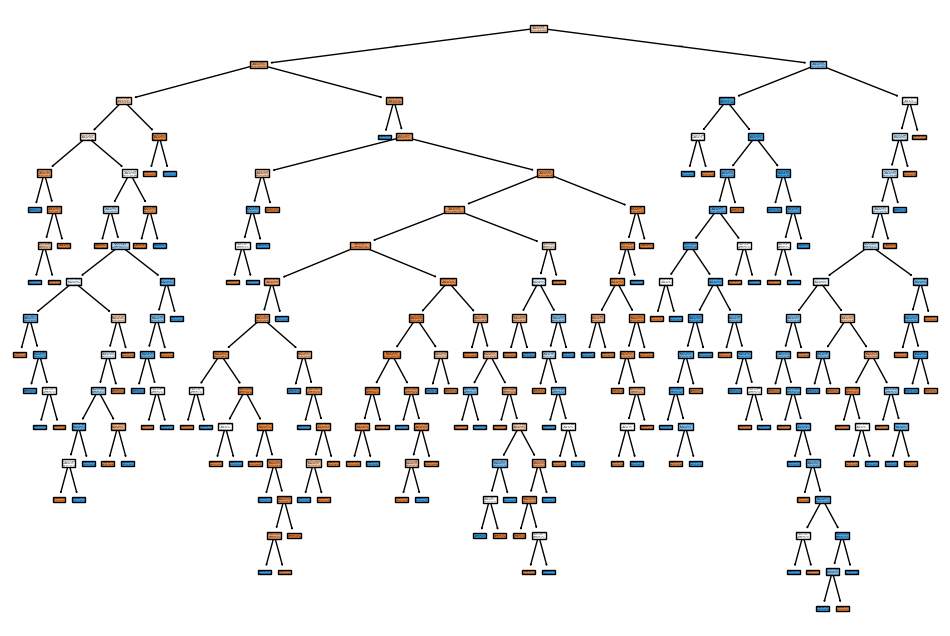

In [45]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(model, filled=True)
plt.show()

I trained a Decision Tree classifier to predict passenger survival. The model learns decision rules from features like passenger class, age, gender, and fare. After training the model on the training dataset, I evaluated its performance using accuracy on the test dataset.

Graph – Survival vs Gender

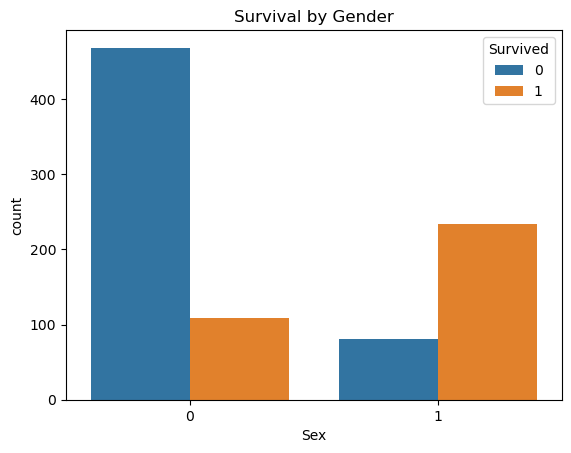

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Sex', hue='Survived', data=df)

plt.title("Survival by Gender")

plt.show()

Survival vs Passenger Class

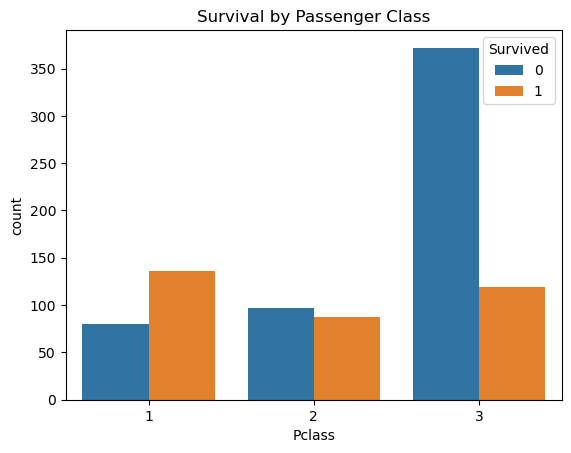

In [47]:
sns.countplot(x='Pclass', hue='Survived', data=df)

plt.title("Survival by Passenger Class")

plt.show()

Age Distribution Graph

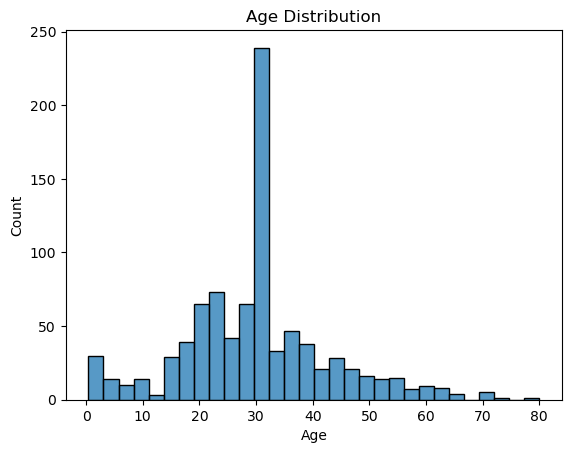

In [48]:
sns.histplot(df['Age'], bins=30)

plt.title("Age Distribution")

plt.show()